# Food Delivery Analytics Validation Notebook

This notebook validates analytical marts generated from the Medallion data pipeline.

Goals:
- Validate SLA breach insights
- Identify delay-driving restaurants
- Understand refund drivers
- Analyse rider performance
- Observe weekly operational trends

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
con = duckdb.connect()

sla = con.execute("SELECT * FROM read_csv_auto('../data/warehouse/sla_breach_analysis.csv')").df()
rest = con.execute("SELECT * FROM read_csv_auto('../data/warehouse/restaurant_prep_delays.csv')").df()
refund = con.execute("SELECT * FROM read_csv_auto('../data/warehouse/refund_drivers.csv')").df()
rider = con.execute("SELECT * FROM read_csv_auto('../data/warehouse/rider_performance.csv')").df()
weekly = con.execute("SELECT * FROM read_csv_auto('../data/warehouse/weekly_trends.csv')").df()

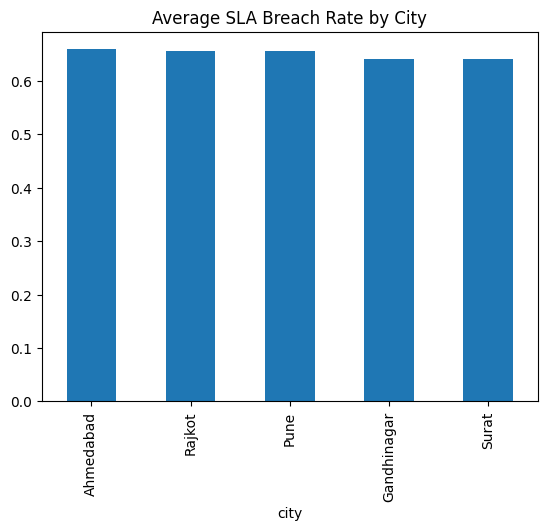

In [8]:
sla_city = sla.groupby("city")["breach_rate"].mean().sort_values(ascending=False)

sla_city.plot(kind="bar", title="Average SLA Breach Rate by City")
plt.show()

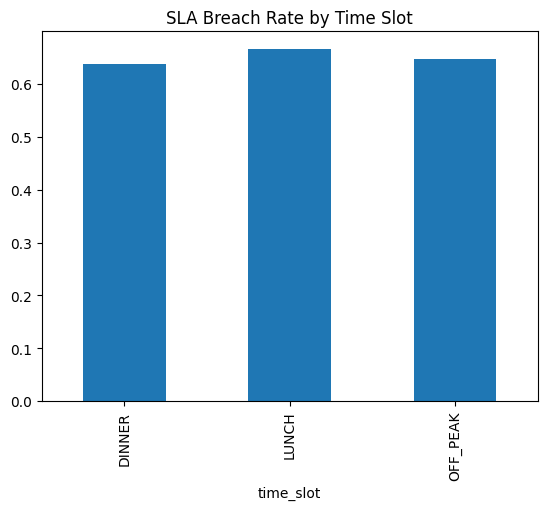

In [9]:
sla_slot = sla.groupby("time_slot")["breach_rate"].mean()

sla_slot.plot(kind="bar", title="SLA Breach Rate by Time Slot")
plt.show()

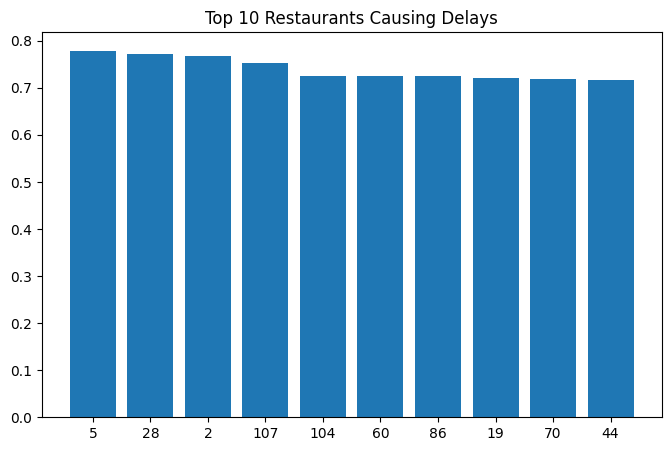

In [11]:
rest_sorted = rest.sort_values("breach_rate", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.bar(rest_sorted["restaurant_id"].astype(str), rest_sorted["breach_rate"])
plt.title("Top 10 Restaurants Causing Delays")
plt.show()

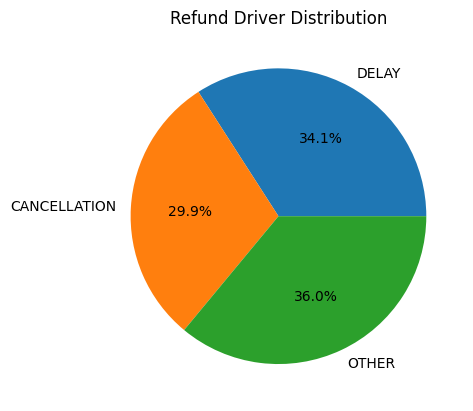

In [12]:
refund.set_index("refund_reason")["refund_rate"].plot(kind="pie", autopct="%1.1f%%")
plt.title("Refund Driver Distribution")
plt.ylabel("")
plt.show()

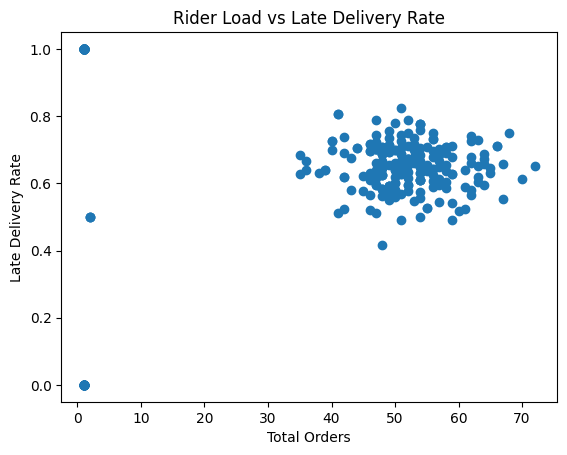

In [13]:
plt.scatter(rider["total_orders"], rider["late_rate"])
plt.title("Rider Load vs Late Delivery Rate")
plt.xlabel("Total Orders")
plt.ylabel("Late Delivery Rate")
plt.show()

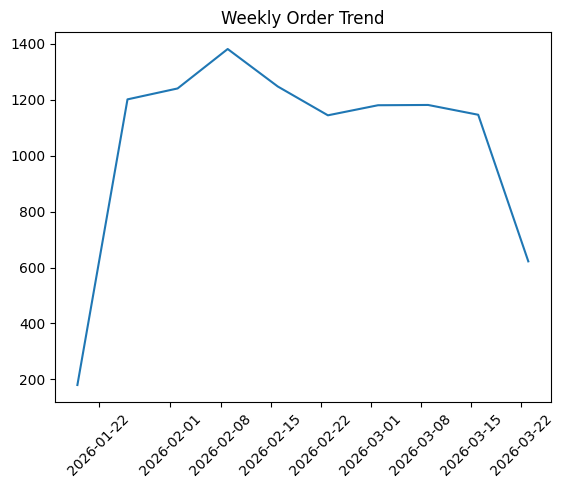

In [14]:
weekly_sorted = weekly.sort_values("week")

plt.plot(weekly_sorted["week"], weekly_sorted["total_orders"])
plt.xticks(rotation=45)
plt.title("Weekly Order Trend")
plt.show()

## Observations

- Certain cities and peak time slots experience higher SLA breach rates.
- A small subset of restaurants contribute disproportionately to delivery delays.
- Delays and cancellations significantly influence refund rates.
- Some riders handle higher order volumes without increasing late deliveries.
- Weekly order volumes and operational metrics show clear trends.

This validates that the analytics pipeline successfully generates actionable business insights.

In [15]:
import os

os.listdir("../data/warehouse")

['refund_drivers.csv',
 'restaurant_prep_delays.csv',
 'rider_performance.csv',
 'sla_breach_analysis.csv',
 'test.db',
 'weekly_trends.csv']

In [16]:
print(sla.columns)
print(rest.columns)
print(refund.columns)
print(rider.columns)
print(weekly.columns)

Index(['city', 'time_slot', 'total_orders', 'breached_orders', 'breach_rate'], dtype='str')
Index(['restaurant_id', 'city', 'total_orders', 'avg_prep_delay',
       'avg_delivery_delay', 'breach_rate'],
      dtype='str')
Index(['refund_reason', 'total_orders', 'refunded_orders', 'refund_rate'], dtype='str')
Index(['rider_id', 'total_orders', 'late_orders', 'successful_orders',
       'avg_delivery_time', 'avg_delay_minutes', 'late_rate'],
      dtype='str')
Index(['week', 'total_orders', 'completed_orders', 'refunded_orders',
       'breached_orders', 'total_refund_amount'],
      dtype='str')


In [17]:
sla.head()
rest.head()
refund.head()
rider.head()
weekly.head()

,week,total_orders,completed_orders,refunded_orders,breached_orders,total_refund_amount
0,2026-01-19,180,171,22,118,7372.60
1,2026-01-26,1201,1144,185,788,58439.45
2,2026-02-02,1240,1165,194,793,59853.25
3,2026-02-09,1381,1316,213,911,66577.91
4,2026-02-16,1247,1180,203,808,65250.41
